_The code for this report is hidden for readability. All source, including the data-processing and model notebooks, is available at the project repository: [github.com/jonahrosenberg/stat-362-final-project](https://github.com/jonahrosenberg/stat-362-final-project)._

## 1) Introduction

Social media posts rarely carry meaning through a single channel. A tweet is often a short caption and an image, and the two together convey a mood that neither might fully express alone. This project asks a focused version of that observation as a machine-learning question: for a tweet that comes with both a caption and an image, which representation carries the most predictable sentiment, the text, the image, or the two combined? To answer it, three parallel classification pipelines are built on the same tweets and compared on identical terms (text-only, image-only, and a multimodal pipeline that fuses the two), each predicting one of three sentiment classes (negative, neutral, positive).

Sentiment analysis is one of the most widely deployed tasks in machine learning, from brand monitoring to content moderation (Pang & Lee, 2008). On the text side, the field has moved from hand-engineered features such as TF-IDF with classical classifiers toward learned representations and pretrained word embeddings (Pennington, Socher, & Manning, 2014). On the image side, convolutional networks and transfer learning from ImageNet-pretrained models are the standard approach for small datasets (Sandler et al., 2018; Tan & Le, 2019). The newer question is multimodal learning, how to combine signals from different data types, now an active research area in its own right (Baltrušaitis, Ahuja, & Morency, 2019). This project is a small, controlled instance of that problem, spanning classical models, recurrent networks, transfer learning, and an ensemble fusion step.

I chose this topic because it forces a question that matters well beyond this dataset: when is more data actually more information? It is tempting to assume a second modality can only help, but that assumption deserves to be tested rather than asserted. A comparative design also teaches something more durable than any single model, namely how to build an evaluation that reveals when an idea did not work, and why.

## 2) Data

### Source

The data is the Twitter Dataset for Sentiment Analysis, published by Dunya Jasim on Kaggle (Jasim, n.d.). It contains 4,869 real tweets, and its defining feature for this project is that every tweet is paired: each carries both a text caption and a corresponding image, labeled with a single sentiment class. This pairing is what makes a controlled comparison across modalities possible, because the text and the image describe the same post and share the same ground-truth label.

### Format and modalities

The dataset combines two input modalities with one categorical target. The text lives in `LabeledText.csv` (read with `latin-1` encoding), which has three columns: `File Name`, `Caption`, and `LABEL`. The images live in `data/Images/`, split across three class subfolders. Text and images are linked by a numeric identifier embedded in the file name, so that `1.txt` in the CSV corresponds to the image `1.jpg` in the appropriate class folder.

The two modalities have very different properties:

- *Text.* The captions are short and informal, averaging about 13 words, and contain the usual social-media noise of URLs, hashtags, mentions, and inconsistent capitalization. Text is a one-dimensional sequence of tokens whose meaning depends on word identity and order.
- *Image.* The images are variable-resolution JPEG files and are visually heterogeneous. They are a mix of ordinary photographs, memes with text overlaid on them, and Snapchat-style screenshots. An image is a three-dimensional array of pixel intensities (height, width, and three color channels), with no inherent alignment to the words in the caption.

The target is a three-class sentiment label. The classes are mildly imbalanced, as shown in @tbl-labels.

| Class | Count | Share |
|---|---|---|
| Neutral | 1,771 | 36.4% |
| Positive | 1,646 | 33.8% |
| Negative | 1,452 | 29.8% |
| Total | 4,869 | 100% |

: Class distribution of the 4,869 tweets. {#tbl-labels}

One paired example per class is shown in @fig-examples, with each image beside its caption. The pairing is what the multimodal pipeline later exploits, and the figure also previews a difficulty that shapes the entire image analysis: the sentiment of a tweet is often carried by the caption, while the image alone can be ambiguous or even unrelated to the mood of the post.

### Why this dataset

This dataset was chosen specifically because it is paired. Most sentiment datasets are single-modality, which makes any text-versus-image comparison confounded by the fact that the two would describe different posts. Here, because each text and image refer to the same tweet and share a label, the comparison isolates the modality itself as the variable of interest. The dataset is also a convenient size: at roughly 4,900 examples it is small enough to train every model on a personal machine, yet large enough that overfitting and data-size effects become real concerns worth studying, which is itself instructive.

### Non-modeling preprocessing

Two kinds of preprocessing are applied before any model sees the data, and neither uses information from the labels or the test set.

For text, each caption is lowercased, stripped of URLs and any non-alphabetic characters, tokenized, and filtered to remove English stopwords and single-character tokens. This cleaning is purely rule-based. A side effect worth noting is that 102 captions reduce to empty strings, because they consisted entirely of links, punctuation, or stopwords. These rows are retained rather than dropped, so that the text and image pipelines operate on the same set of tweets.

For images, each file is decoded to three color channels and resized to a fixed 128 by 128 pixels using Lanczos resampling, since the models require a uniform input shape. Pixel values are then rescaled, either to the unit interval for the from-scratch network or to the range expected by each pretrained model. The resolution of 128 pixels is a deliberate compromise: it preserves enough detail for photograph-style images while keeping memory and training time manageable. It is worth stating plainly that no feasible resolution would let a convolutional network read the small overlaid caption text in the meme-style images, a point returned to in the discussion.

Finally, the data is divided with a stratified split using a fixed random seed, holding out 20% as a test set and reserving a further portion of the training data for validation. Stratification preserves the class proportions in every split, and the fixed seed makes the evaluation reproducible. The exact splitting protocol, including how it differs between the single-modality and multimodal pipelines, is described in the Methods section.

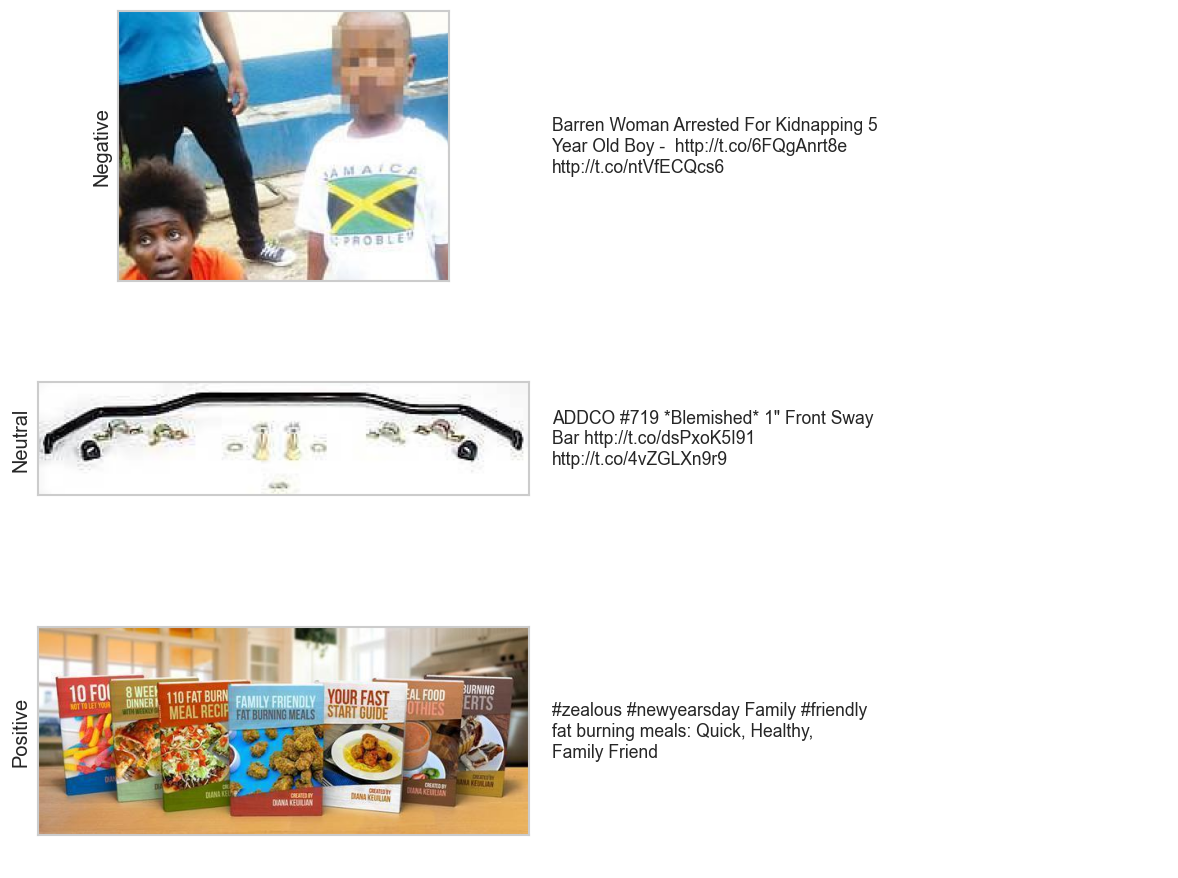

In [10]:
#| label: fig-examples
#| fig-cap: "Paired tweet examples: one image and its caption per sentiment class. The caption frequently carries the sentiment more clearly than the image."
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

meta = pd.read_csv('data/LabeledText.csv', encoding='latin-1')
meta['file_id'] = meta['File Name'].str.replace('.txt', '', regex=False)
label_to_folder = {'negative': 'Negative', 'neutral': 'Neutral', 'positive': 'positive'}

# One paired example per class, chosen for a readable, moderate-length caption
fig, axes = plt.subplots(3, 2, figsize=(10, 7.5), gridspec_kw={'width_ratios': [1, 1.25]})
for r, label in enumerate(['negative', 'neutral', 'positive']):
    sub = meta[(meta['LABEL'].str.lower() == label) &
               (meta['Caption'].astype(str).str.split().apply(len).between(6, 18))]
    row = sub.sample(1, random_state=42).iloc[0]
    img_path = os.path.join('data/Images', label_to_folder[label], f"{row['file_id']}.jpg")

    img = Image.open(img_path).convert('RGB')
    axes[r][0].imshow(img)
    axes[r][0].set_xticks([])
    axes[r][0].set_yticks([])
    axes[r][0].set_ylabel(label.capitalize(), fontsize=12)

    axes[r][1].axis('off')
    caption = textwrap.fill(str(row['Caption']).strip(), width=38)
    axes[r][1].text(0.0, 0.5, caption, va='center', ha='left', fontsize=10.5)

plt.tight_layout()
plt.show()

## 3) Methods

### Task and variables

The task is supervised multiclass classification. The response variable is the sentiment label, which takes one of three values (negative, neutral, positive). The predictors differ by pipeline: the text pipeline predicts from the caption alone, the image pipeline predicts from the image alone, and the multimodal pipeline predicts from both. Because the same labeled tweets feed all three pipelines, any difference in performance can be attributed to the representation rather than to the data.

### Evaluation protocol and metrics

Every model is held to the same protocol so that results are comparable. The data is split once into a training portion and a test portion, with 20% held out for testing, stratified by class and fixed with a random seed so the test set never changes. For models with hyperparameters to tune, a validation set is carved from the training portion using the same 20% proportion and seed. Hyperparameters are selected on the validation set, after which the chosen model is retrained on the combined training and validation data before a single, final evaluation on the test set. A single held-out validation set is used rather than k-fold cross-validation, partly for consistency across the classical and deep models so they are judged identically, and partly because the deep networks are too costly to train many times over. The cost of this choice is a noisier estimate of validation performance, an issue that becomes relevant when tuning the fusion weight later.

Two metrics summarize performance: accuracy and the macro-averaged F1 score. Accuracy is the fraction of test tweets classified correctly. On its own accuracy can be misleading under class imbalance, because a model can score reasonably well simply by favoring the largest class, so the macro F1 score is reported alongside it. For each class, precision is the share of predictions for that class that are correct, recall is the share of true members of that class that are recovered, and the F1 score is their harmonic mean, which is high only when both are high. The macro F1 score averages the per-class F1 scores with equal weight, so a model that ignores a minority class is penalized regardless of how common that class is. Per-class F1 scores are also examined directly, because they reveal failure modes that a single summary number hides, such as a model that predicts only the majority class. As a reference point, every comparison includes a majority-class baseline that always predicts the most common label (neutral); any model that cannot beat it has learned nothing useful.

### Text pipeline

The text pipeline spans two families of model that differ in how they represent a caption. The classical models use a term frequency-inverse document frequency (TF-IDF) representation, which turns each caption into a sparse vector over the training vocabulary, weighting each word by how often it appears in the caption and downweighting words that are common across all captions. This is a form of explicit feature engineering, and the vocabulary and weights are learned from the training data only, so no information leaks from the test set. On top of these features three standard classifiers are trained. Multinomial naive Bayes treats the features as word counts and applies Bayes' rule under the simplifying assumption that words are conditionally independent given the class. Logistic regression fits a linear decision boundary by modeling class log-odds as a weighted sum of the features, with an L2 penalty whose strength is set by the regularization parameter C. A linear support vector machine separates classes by the hyperplane that maximizes the margin between them, again tuned through C (Cortes & Vapnik, 1995). A multilayer perceptron, a small fully connected neural network, is also trained on the same features as a nonlinear classical comparison.

The neural models instead represent a caption as a sequence. Each caption is tokenized and padded to a fixed length, and each token is mapped to a dense vector. The first neural model is a plain recurrent neural network (RNN), which reads the sequence one token at a time while maintaining a hidden state, and learns its word vectors from scratch. The second replaces the recurrent unit with a long short-term memory (LSTM) cell, which adds gating mechanisms that let it retain or forget information across longer spans and largely avoids the vanishing-gradient problem of plain RNNs (Hochreiter & Schmidhuber, 1997). Crucially, the LSTM's word vectors are initialized from GloVe, a set of 100-dimensional embeddings pretrained on six billion tokens of general text that place semantically related words near one another (Pennington, Socher, & Manning, 2014). These embeddings are held fixed during training, so the model inherits a useful notion of word meaning rather than having to learn one from a few thousand short captions. The full set of text models is summarized in @tbl-text-models.

| Model | Family | Representation | Tuned hyperparameter |
|---|---|---|---|
| Baseline | Reference | none (predicts majority class) | none |
| Multinomial Naive Bayes | Classical | TF-IDF | none |
| Logistic Regression | Classical | TF-IDF | C (L2 strength) |
| Linear SVM | Classical | TF-IDF | C (margin) |
| Multilayer Perceptron | Neural (dense) | TF-IDF | none |
| RNN (plain) | Neural (recurrent) | embeddings learned from scratch | hidden units |
| GloVe + LSTM | Neural (recurrent) | frozen GloVe embeddings | LSTM units |

: Models in the text pipeline. {#tbl-text-models}

### Image pipeline

The image pipeline takes the 128 by 128 pixel arrays as input and likewise spans a from-scratch model and transfer-learning models. The from-scratch model is a convolutional neural network (CNN). A CNN slides small learnable filters across the image to detect local patterns such as edges and textures, stacks several such convolutional layers so that later layers compose simple patterns into more complex ones, and uses pooling layers to progressively reduce spatial resolution while retaining the strongest responses. The network used here applies three convolutional blocks followed by fully connected layers that map the learned features to the three sentiment classes. Because a network trained from scratch must learn all of its visual features from only a few thousand images, it is prone to either overfitting or collapse on a dataset this small.

The transfer-learning models address that limitation by reusing visual features already learned on a much larger corpus. Both MobileNetV2 (Sandler et al., 2018) and EfficientNetB0 (Tan & Le, 2019) are convolutional networks pretrained on ImageNet, a dataset of more than a million labeled photographs (Deng et al., 2009). For this project their pretrained convolutional layers are frozen and used as a fixed feature extractor, a global average pooling layer condenses the spatial feature maps into a single vector, and a small trainable classification head is added on top. The head consists of a dense layer with L2 regularization, a dropout layer that randomly zeros half of its inputs during training to discourage co-adaptation and overfitting (Srivastava et al., 2014), and a final layer producing class probabilities. All neural models are trained with the Adam optimizer at a low learning rate (Kingma & Ba, 2015) and use early stopping, which halts training when validation loss stops improving. The image models are summarized in @tbl-image-models. One honest methodological detail is worth recording: the two transfer models differ in their final-retraining early-stopping signal. MobileNetV2 reused the fixed validation set, which with so few images it memorized, so early stopping never triggered; EfficientNetB0 was therefore switched to carve a fresh validation slice from its training data at fit time, giving early stopping a signal the model had not already seen. A logistic-regression classifier on raw flattened pixels was also attempted, but it was abandoned because fitting on roughly fifty thousand dense pixel features per image was prohibitively slow, which itself illustrates why classical models are ill-suited to raw image data.

| Model | Approach | Feature source | Tuned hyperparameter |
|---|---|---|---|
| Baseline | Reference | none (predicts majority class) | none |
| CNN (scratch) | Trained from scratch | features learned from pixels | convolutional filter count |
| MobileNetV2 | Transfer learning | frozen ImageNet backbone | dense head size |
| EfficientNetB0 | Transfer learning | frozen ImageNet backbone | dense head size |

: Models in the image pipeline. {#tbl-image-models}

### Multimodal pipeline

The multimodal pipeline combines the strongest text model (the GloVe-initialized LSTM) and the strongest image model (MobileNetV2) by late fusion, meaning each model first produces its own class-probability vector for a tweet and the two vectors are then combined into a single prediction. Late fusion is a natural fit here because the two modalities have incompatible raw forms but produce comparable outputs, namely a probability over the same three classes. To keep the comparison honest, the multimodal pipeline does not reuse the separate text and image test sets; instead it builds one combined table that joins each caption to its image by numeric identifier and performs a single joint split, so that both base models are trained and evaluated on exactly the same tweets.

Three fusion strategies are compared, in increasing order of flexibility, and are summarized in @tbl-fusion. The first is an equal average of the two probability vectors. The second is a weighted average that assigns weight to the text model and the remainder to the image model, with the weight chosen on the validation set. The third is stacking, in which the two probability vectors are concatenated into a six-dimensional feature vector and a logistic-regression meta-classifier is trained to map it to the final prediction, allowing each modality's per-class probabilities to be weighted independently rather than through a single shared coefficient (Wolpert, 1992). For the weighted and stacking strategies the fusion parameters must be fit on data the base models have not already seen, so for these the base models are trained on the training portion alone and the validation set is held back to tune the weight or fit the meta-classifier. Training the base models on the full training-plus-validation data instead would let them memorize the validation set and make any tuning on it meaningless. All implementations use scikit-learn for the classical models and metrics (Pedregosa et al., 2011) and TensorFlow with Keras for the neural networks (Abadi et al., 2016).

| Strategy | How the two probability vectors are combined | Parameters fit on |
|---|---|---|
| Equal average | mean of the text and image probabilities | none |
| Weighted average | weight on text, remainder on image | fusion weight tuned on validation |
| Stacking | logistic regression on the concatenated probabilities | meta-classifier fit on validation |

: Late-fusion strategies in the multimodal pipeline. {#tbl-fusion}

## 4) Results and Discussion

Across the three pipelines, thirteen model configurations were trained and evaluated under the shared protocol. @tbl-results reports every model's test accuracy and F1 scores grouped by pipeline, @fig-accuracy shows the accuracy of each model with the majority-class baseline marked, and @fig-classf1 breaks performance down by sentiment class. Three patterns stand out immediately: the text models occupy the entire top of the ranking, the image models cluster just above the baseline, and the multimodal models land at the level of the text models rather than above them.

In [11]:
#| label: results-setup
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

# Load every model's saved metadata, tagged by pipeline
pipelines = {'text': 'Text', 'images': 'Image', 'both': 'Multimodal'}
records = []
for folder, label in pipelines.items():
    d = f'models/{folder}/json'
    for fn in sorted(os.listdir(d)):
        if fn.endswith('_meta.json'):
            with open(os.path.join(d, fn)) as f:
                m = json.load(f)
            m['Pipeline'] = label
            records.append(m)
df = pd.DataFrame(records)

# Collapse the two identical majority-class baselines into one reference row
base_mask = df['model'] == 'baseline'
keep = df[base_mask].iloc[[0]].copy()
keep['Pipeline'] = 'Baseline'
df = pd.concat([df[~base_mask], keep], ignore_index=True)

name_map = {
    'baseline': 'Baseline', 'naive_bayes': 'Naive Bayes',
    'logistic_regression': 'Logistic Regression', 'svm': 'SVM',
    'mlp_text': 'MLP', 'rnn_text': 'RNN (plain)', 'glove_rnn_text': 'GloVe + LSTM',
    'cnn_scratch': 'CNN (scratch)', 'cnn_mobilenet': 'MobileNetV2',
    'cnn_efficientnet': 'EfficientNetB0',
    'multimodal_late_fusion': 'Late Fusion (avg)',
    'multimodal_weighted_fusion': 'Weighted Fusion',
    'multimodal_stacking': 'Stacking',
}
df['Model'] = df['model'].map(name_map)
df = df.rename(columns={
    'accuracy': 'Accuracy', 'macro_f1': 'Macro F1',
    'negative_f1': 'Neg F1', 'neutral_f1': 'Neu F1', 'positive_f1': 'Pos F1',
    'runtime_seconds': 'Runtime (s)',
})

pipeline_palette = {'Baseline': '#bdbdbd', 'Text': '#4c72b0', 'Image': '#dd8452', 'Multimodal': '#55a868'}
pipeline_order = ['Baseline', 'Text', 'Image', 'Multimodal']
df = df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
baseline_acc = df.loc[df['Model'] == 'Baseline', 'Accuracy'].values[0]

In [12]:
#| label: tbl-results
#| tbl-cap: "Test-set performance and training time of all thirteen model configurations, sorted by accuracy. Per-class F1 scores reveal which models collapse onto a single class; runtime includes hyperparameter tuning."
res = df[['Model', 'Pipeline', 'Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1', 'Runtime (s)']].copy()
for col in ['Accuracy', 'Macro F1', 'Neg F1', 'Neu F1', 'Pos F1']:
    res[col] = res[col].round(3)
res['Runtime (s)'] = res['Runtime (s)'].round(1)
res = res.reset_index(drop=True)
res.index = res.index + 1
res

,Model,Pipeline,Accuracy,Macro F1,Neg F1,Neu F1,Pos F1,Runtime (s)
1,GloVe + LSTM,Text,0.733,0.732,0.719,0.673,0.805,169.9
2,Stacking,Multimodal,0.707,0.710,0.681,0.645,0.804,235.7
3,Logistic Regression,Text,0.700,0.701,0.683,0.646,0.774,1.4
4,Weighted Fusion,Multimodal,0.695,0.696,0.673,0.637,0.779,276.8
5,SVM,Text,0.682,0.682,0.654,0.620,0.772,3.2
6,Late Fusion (avg),Multimodal,0.677,0.675,0.634,0.637,0.754,431.9
7,Naive Bayes,Text,0.672,0.670,0.651,0.615,0.742,0.0
8,MLP,Text,0.664,0.666,0.657,0.609,0.733,419.4
9,MobileNetV2,Image,0.419,0.418,0.393,0.431,0.431,1771.0
10,RNN (plain),Text,0.383,0.223,0.128,0.540,0.000,90.4


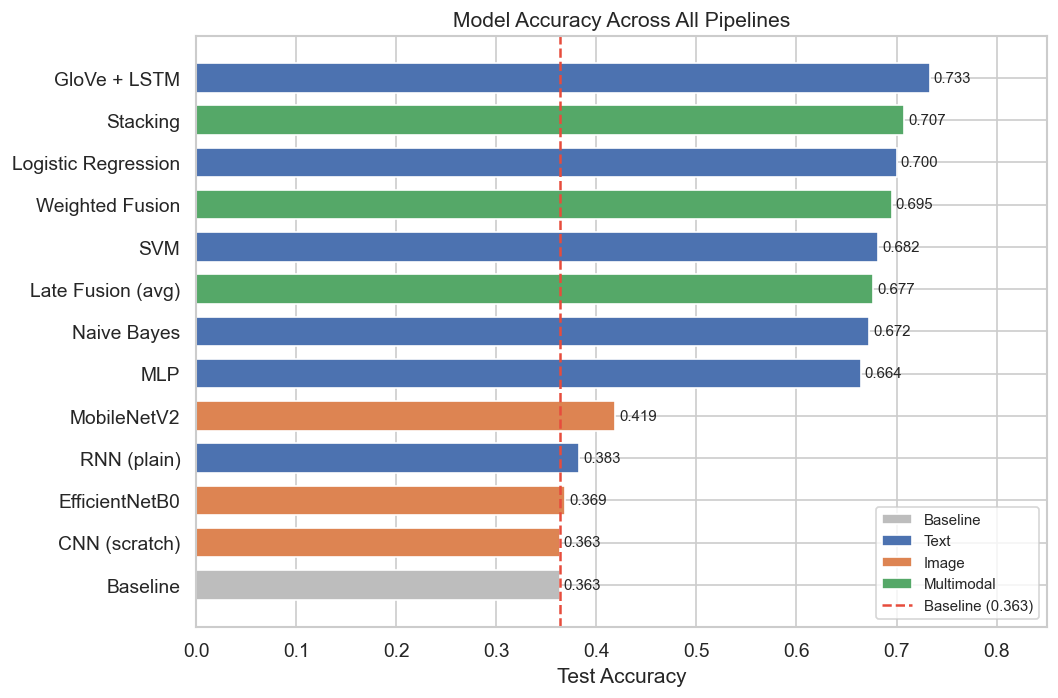

In [13]:
#| label: fig-accuracy
#| fig-cap: "Test accuracy of every model, colored by pipeline. The dashed line is the majority-class baseline. Text models lead, image models sit near the baseline, and the multimodal models match the text models."
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = df.sort_values('Accuracy')
bars = ax.barh(plot_df['Model'], plot_df['Accuracy'],
               color=[pipeline_palette[p] for p in plot_df['Pipeline']],
               edgecolor='white', height=0.7)
ax.axvline(baseline_acc, color='#e74c3c', linestyle='--', linewidth=1.5)
for bar, val in zip(bars, plot_df['Accuracy']):
    ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Test Accuracy')
ax.set_title('Model Accuracy Across All Pipelines')
ax.set_xlim(0, 0.85)
legend_elements = [Patch(facecolor=pipeline_palette[p], label=p) for p in pipeline_order]
legend_elements.append(plt.Line2D([0], [0], color='#e74c3c', linestyle='--',
                                  label=f'Baseline ({baseline_acc:.3f})'))
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

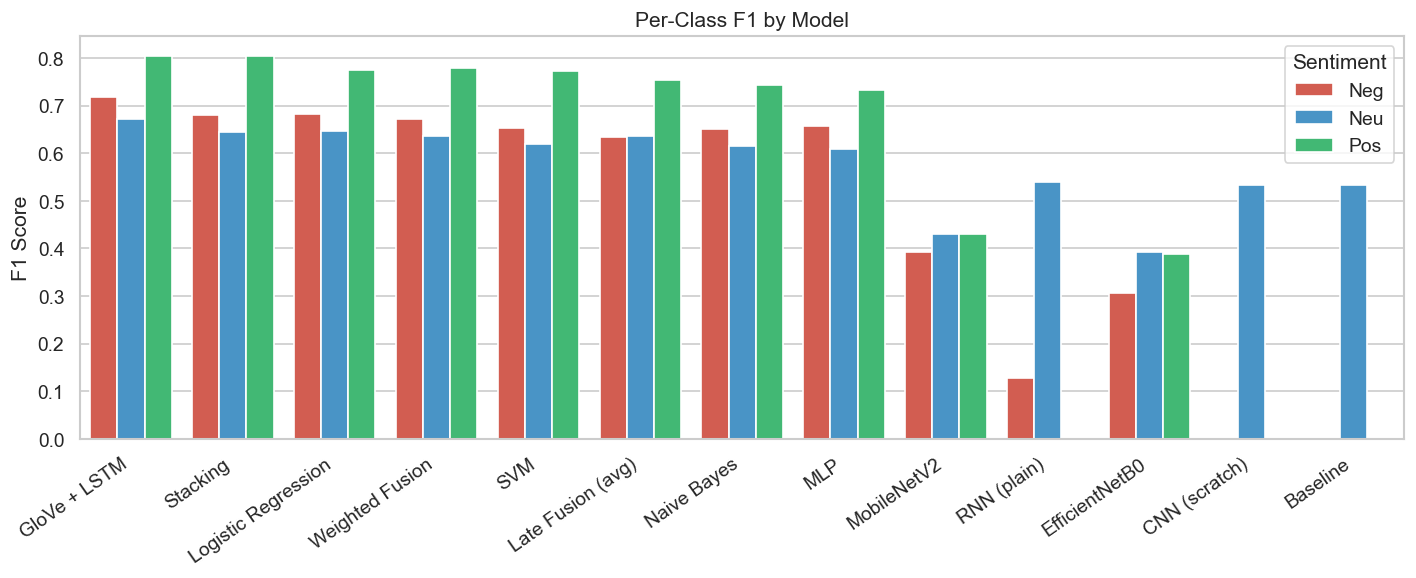

In [14]:
#| label: fig-classf1
#| fig-cap: "Per-class F1 score by model. A score of zero on the negative and positive classes (the baseline and the from-scratch CNN, and nearly the plain RNN) marks a model that has collapsed onto predicting only the majority neutral class."
f1_melt = df.melt(id_vars='Model', value_vars=['Neg F1', 'Neu F1', 'Pos F1'],
                  var_name='Class', value_name='F1')
f1_melt['Class'] = f1_melt['Class'].str.replace(' F1', '')
order = df['Model'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=f1_melt, x='Model', y='F1', hue='Class', order=order,
            palette={'Neg': '#e74c3c', 'Neu': '#3498db', 'Pos': '#2ecc71'},
            ax=ax, edgecolor='white')
ax.set_xlabel('')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 by Model')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=35, ha='right')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

### Text: representation matters more than model complexity

The text pipeline is clearly successful. The best model, the GloVe-initialized LSTM, reaches 73.3% accuracy and a macro F1 of 0.732, roughly double the baseline. What is more interesting than the winner is the ordering beneath it. The three classical models on TF-IDF features, logistic regression (70.0%), the support vector machine (68.2%), and naive Bayes (67.2%), all comfortably outperform the plain recurrent network, which manages only 38.3% and, as @fig-classf1 shows, nearly collapses onto the neutral class.

This inversion, where simple linear models on engineered features beat a neural sequence model, is the central lesson of the text pipeline. TF-IDF encodes a piece of human knowledge directly into the representation: that a word's importance is tied to how often it appears here relative to everywhere else. A plain RNN is handed no such prior and must discover everything, including useful word vectors, from only about three thousand short captions. That is far too little data for the task, so it learns little and defaults toward the majority class. On small, short-text problems, explicit features paired with simple classifiers tend to win, and only with much larger corpora does learning the representation from scratch pay off.

The GloVe-initialized LSTM is the exception that proves the rule. It is also a sequence model, but instead of learning word vectors from scratch it starts from embeddings pretrained on six billion tokens, which encode a great deal of semantic structure for free. Swapping random initialization for GloVe is the difference between 38.3% and 73.3%, a direct demonstration of why transfer learning is so valuable when data is scarce.

### Image: a principled ceiling, not a tuning failure

The image pipeline tells the opposite story. No image model meaningfully clears the baseline. The best, MobileNetV2, reaches only 41.9%, EfficientNetB0 lands at 36.9%, and the from-scratch CNN collapses entirely to 36.3%, predicting nothing but neutral, with negative and positive F1 scores of exactly zero in @fig-classf1. The from-scratch collapse mirrors the plain RNN on the text side: a network with no prior knowledge cannot learn useful features from a few thousand examples. Transfer learning helps, lifting MobileNetV2 a few points above the baseline, but only marginally, which is the result worth explaining.

The explanation is a property of the data rather than a deficiency of the models. As @fig-examples illustrated, a large share of these images are memes and screenshots whose sentiment lives in caption text printed onto the picture. A convolutional network recognizes shapes, textures, and objects; it does not read text, and at any resolution feasible here the overlaid words are not legible to it. The remaining photograph-style images often have no visual sentiment cue at all, since a neutral-looking photo can accompany a strongly negative or positive caption. The pretrained backbones are genuinely good at recognizing the contents of a photograph, but recognizing contents is not the same as inferring the mood of the post, and for this dataset the two are weakly related. The image ceiling is therefore principled and was anticipated: the modality simply does not carry much recoverable sentiment signal.

### Multimodal: fusion inherits the stronger modality

If the image modality carries little signal, multimodal fusion cannot be expected to improve on text, and it does not. @tbl-fusion-results compares each of the three fusion strategies with its own text-only and image-only base models on the identical joint test set. In every case fusion fails to exceed text alone. The clearest result is stacking: the meta-classifier reaches 70.7% accuracy, which is exactly the text-only accuracy on the same split (both correspond to 689 of 974 tweets classified correctly). Fusion neither helps nor hurts; it simply reproduces the text model's predictions.

Two details make the result more than a single coincidence. First, the equal average and the weighted average also fail to beat text, and the weighted average actually lands slightly below it. The fusion weight was tuned on the validation set, but the validation accuracy is nearly flat for any weight that keeps text dominant, so the procedure chose a weight that gave the near-useless image probabilities too much influence and dragged the result down. A one-standard-error rule, which prefers the simplest model whose validation score is within one standard error of the best, would have selected pure text. Second, the stacking meta-classifier did not simply zero out the image inputs: the total magnitude of its text coefficients exceeds that of its image coefficients by only about a factor of two. The image probabilities are nonetheless ignored in effect, because the image model outputs near-uniform, low-confidence probabilities that barely move the decision regardless of the weight placed on them. A modality that is close to noise cannot contribute to an ensemble at any weighting, which is exactly what these three experiments show from three different angles.

In [15]:
#| label: tbl-fusion-results
#| tbl-cap: "Each fusion strategy against its own text-only and image-only base models on the identical joint test set. Fusion never exceeds text alone; the weighted average falls slightly below it. Text-only references vary by a few points across rows due to run-to-run variation in neural training and differences in how much data each experiment's base models saw."
fusion_rows = []
strategy_names = {
    'multimodal_late_fusion': 'Equal average',
    'multimodal_weighted_fusion': 'Weighted average',
    'multimodal_stacking': 'Stacking',
}
order = ['multimodal_late_fusion', 'multimodal_weighted_fusion', 'multimodal_stacking']
meta_by_model = {r['model']: r for r in records if r['model'] in order}
for key in order:
    m = meta_by_model[key]
    fusion_rows.append({
        'Strategy': strategy_names[key],
        'Fusion accuracy': round(m['accuracy'], 3),
        'Text only (same split)': round(m['text_acc_joint_test'], 3),
        'Image only (same split)': round(m['img_acc_joint_test'], 3),
    })
fusion_tbl = pd.DataFrame(fusion_rows)
fusion_tbl.index = fusion_tbl.index + 1
fusion_tbl

,Strategy,Fusion accuracy,Text only (same split),Image only (same split)
1,Equal average,0.677,0.678,0.389
2,Weighted average,0.695,0.705,0.374
3,Stacking,0.707,0.707,0.370


### Overall comparison, success, and limitations

@fig-champions places the strongest model from each pipeline side by side, and the training times in @tbl-results complete the picture. Text is the decisive modality: the GloVe-initialized LSTM is both the most accurate model and, at under three minutes of training, far cheaper than the image networks, which took between thirteen and twenty-nine minutes to land near the baseline. The compute spent on the image modality bought essentially nothing, a useful finding in itself about where effort is worth spending on this kind of data.

Whether the workflow succeeded depends on the pipeline. The text pipeline is a clear success, doubling the baseline and demonstrating both the value of engineered features on small data and the value of pretrained embeddings. The image pipeline did not succeed in absolute terms, but it failed for a diagnosed reason rather than a fixable mistake: the sentiment in these images is largely encoded in text a convolutional network cannot read. The multimodal pipeline succeeded as an experiment even though fusion did not improve accuracy, because it answers the project's central question cleanly. Combining a strong modality with a near-noise one yields no gain at any fusion weight, so the original hypothesis that multimodal would beat either modality alone is rejected for this dataset.

Several limitations qualify these conclusions. The dataset is small, which is why the from-scratch models collapsed and why tuning relied on a single noisy validation set rather than cross-validation. The text-only and image-only pipelines used independently drawn test sets, so a small part of the gap between them could reflect the split rather than a true difference between modalities; the multimodal pipeline avoids this with one joint split, and the difference between the text model's 73.3% on its own split and 70.7% on the joint split shows that a few points of variation come from the split alone. The most consequential limitation is the image ceiling itself. The natural ways to break it would be to read the overlaid caption text with optical character recognition, or to use a vision-language model such as CLIP that is trained to align images with text and can interpret meme-style images far better than a plain convolutional network. Both were out of scope here, the first because it turns the image task into a text task and the second because of its added complexity and compute, but either is the clear next step for recovering signal from this kind of image.

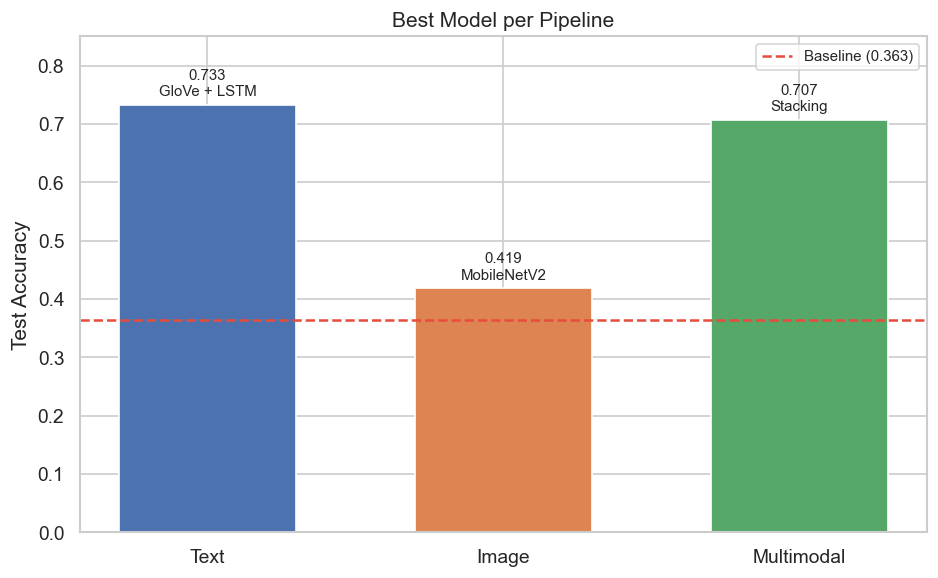

In [16]:
#| label: fig-champions
#| fig-cap: "The best model from each pipeline on its test set. Text wins decisively, the image champion barely clears the baseline, and the multimodal champion matches but does not exceed text."
champ_pool = df[df['Pipeline'] != 'Baseline']
champions = champ_pool.loc[champ_pool.groupby('Pipeline')['Accuracy'].idxmax()].copy()
champions['Pipeline'] = pd.Categorical(champions['Pipeline'],
                                       categories=['Text', 'Image', 'Multimodal'], ordered=True)
champions = champions.sort_values('Pipeline')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(champions['Pipeline'].astype(str), champions['Accuracy'],
              color=[pipeline_palette[p] for p in champions['Pipeline'].astype(str)],
              edgecolor='white', width=0.6)
ax.axhline(baseline_acc, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Baseline ({baseline_acc:.3f})')
for bar, (_, row) in zip(bars, champions.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{row['Accuracy']:.3f}\n{row['Model']}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Test Accuracy')
ax.set_title('Best Model per Pipeline')
ax.set_ylim(0, 0.85)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 5) Conclusion

This project asked which representation of a paired tweet carries the most predictable sentiment, and built text, image, and multimodal pipelines to answer it. The text pipeline was the clear winner, reaching 73.3% accuracy with a GloVe-initialized LSTM, roughly double the majority-class baseline. The image pipeline never rose meaningfully above that baseline, because the sentiment in these images is largely written in overlaid caption text that a convolutional network cannot read. Multimodal late fusion, across equal-average, weighted, and stacking strategies, matched the text model but never exceeded it, since combining a strong modality with a near-noise one cannot help at any weighting.

The work also illustrates several core machine-learning ideas in miniature. On small, short-text data, TF-IDF features with simple classifiers outperformed a recurrent network trained from scratch, and pretrained GloVe embeddings were what lifted the LSTM from near-collapse to the best result, a direct demonstration of transfer learning's value when data is scarce. The same pattern held for images, where frozen ImageNet backbones beat a from-scratch CNN. Most importantly, the negative multimodal result answers the motivating question honestly: more data is only more information when the added modality actually carries signal, and here it did not.

## References

Abadi, M., Agarwal, A., Barham, P., et al. (2016). TensorFlow: Large-scale machine learning on heterogeneous distributed systems. arXiv:1603.04467.

Baltrušaitis, T., Ahuja, C., & Morency, L.-P. (2019). Multimodal machine learning: A survey and taxonomy. IEEE Transactions on Pattern Analysis and Machine Intelligence, 41(2), 423–443.

Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), 273–297.

Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L. (2009). ImageNet: A large-scale hierarchical image database. In 2009 IEEE Conference on Computer Vision and Pattern Recognition (pp. 248–255).

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation, 9(8), 1735–1780.

Jasim, D. (n.d.). Twitter dataset for sentiment analysis [Data set]. Kaggle. https://www.kaggle.com/datasets/dunyajasim/twitter-dataset-for-sentiment-analysis

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. In International Conference on Learning Representations (ICLR).

Pang, B., & Lee, L. (2008). Opinion mining and sentiment analysis. Foundations and Trends in Information Retrieval, 2(1–2), 1–135.

Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global vectors for word representation. In Proceedings of the 2014 Conference on Empirical Methods in Natural Language Processing (EMNLP) (pp. 1532–1543). https://nlp.stanford.edu/projects/glove/

Sandler, M., Howard, A., Zhu, M., Zhmoginov, A., & Chen, L.-C. (2018). MobileNetV2: Inverted residuals and linear bottlenecks. In Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR) (pp. 4510–4520).

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. Journal of Machine Learning Research, 15(1), 1929–1958.

Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. In Proceedings of the 36th International Conference on Machine Learning (ICML) (pp. 6105–6114).

Wolpert, D. H. (1992). Stacked generalization. Neural Networks, 5(2), 241–259.